In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

In [ ]:
df=pd.read_csv('data/Rainfall.csv')

In [ ]:
df.head(5)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
df.isnull().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [ ]:
df=df.drop(['day'],axis=1)

In [ ]:
df

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
...,...,...,...,...,...,...,...,...,...,...,...
361,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9


In [ ]:
df.columns = df.columns.str.strip()
df['winddirection']=df['winddirection'].fillna(df['winddirection'].mode()[0])

In [ ]:
df['windspeed']=df['windspeed'].fillna(df['windspeed'].median())

In [ ]:
print(df.isnull().sum())

pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64


In [ ]:
df['rainfall'].unique()

array(['yes', 'no'], dtype=object)

In [ ]:
df['rainfall'] = df['rainfall'].replace({'yes': 1, 'no': 0})

/tmp/ipython-input-1474088430.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['rainfall'] = df['rainfall'].replace({'yes': 1, 'no': 0})


In [ ]:
df.head(5)

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


In [ ]:
df.shape

(366, 11)

In [ ]:
sns.set(style="whitegrid")


In [ ]:
df.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

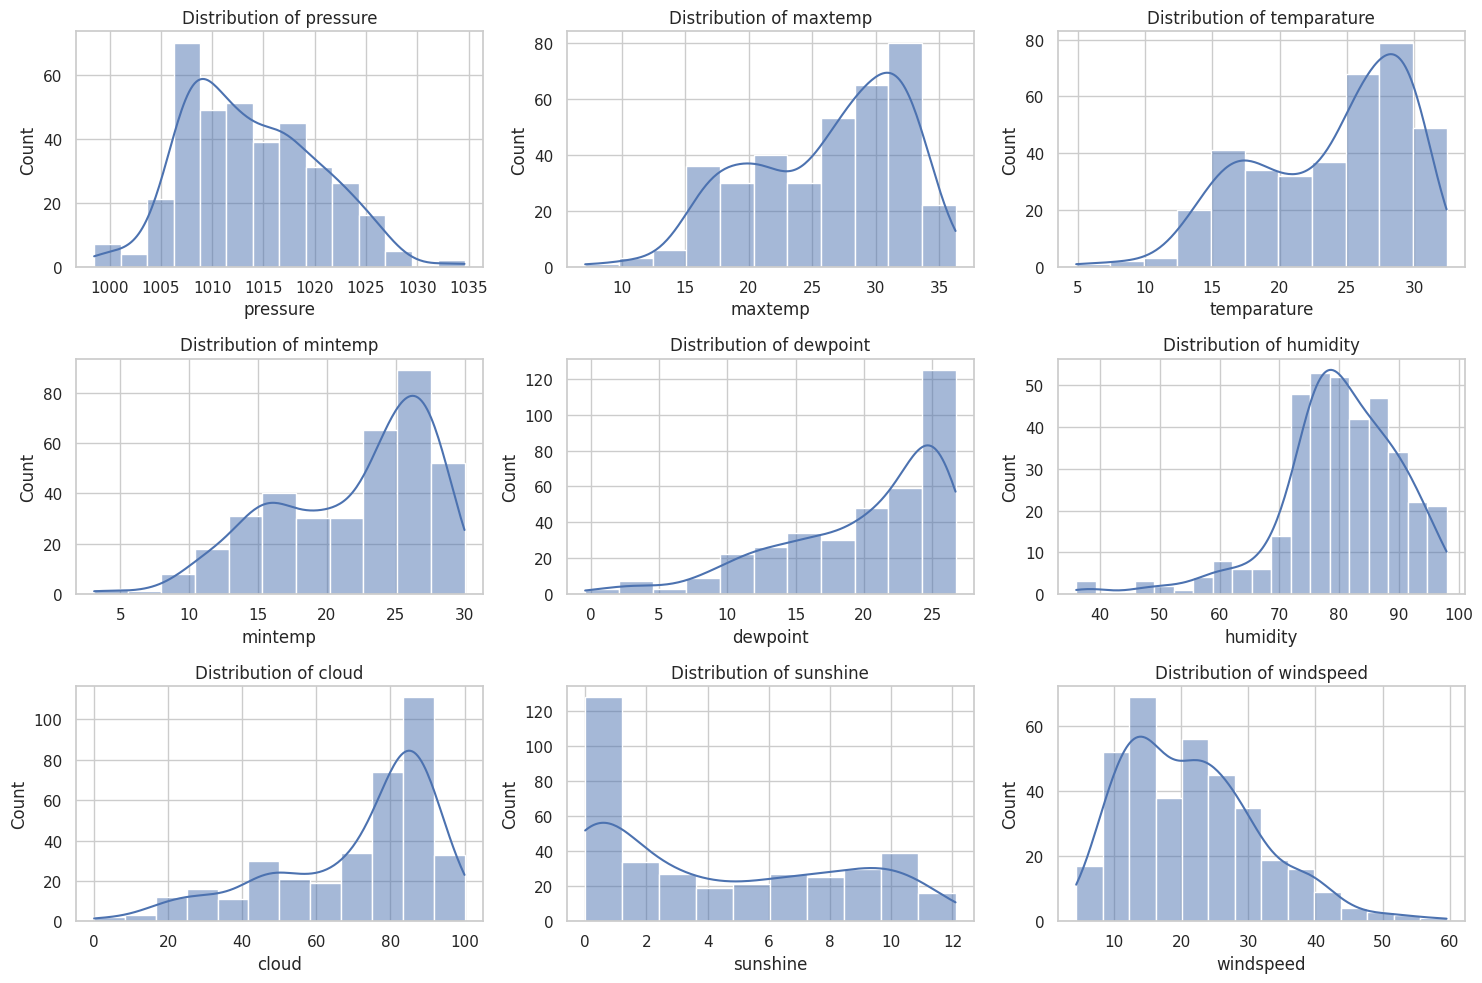

In [ ]:
plt.figure(figsize=(15,10))
for index, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine',  'windspeed']):
  plt.subplot(3,3,index + 1)
  sns.histplot(df[column],kde=True)
  plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [ ]:
df['rainfall'].value_counts()

,count
rainfall,
1,249
0,117


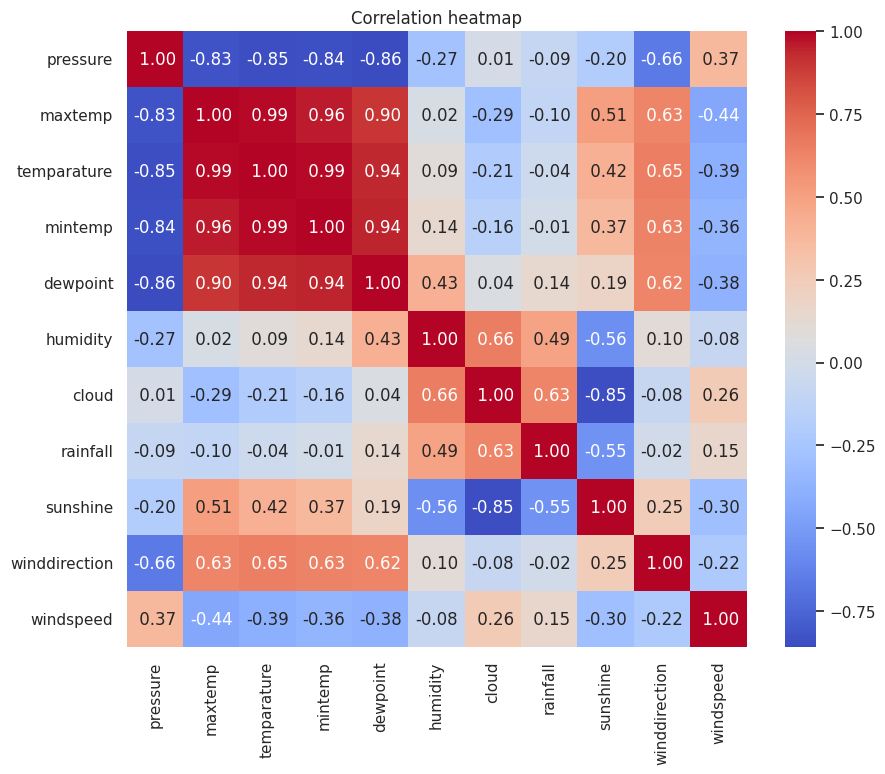

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm", fmt=" .2f")
plt.title("Correlation heatmap")
plt.show()

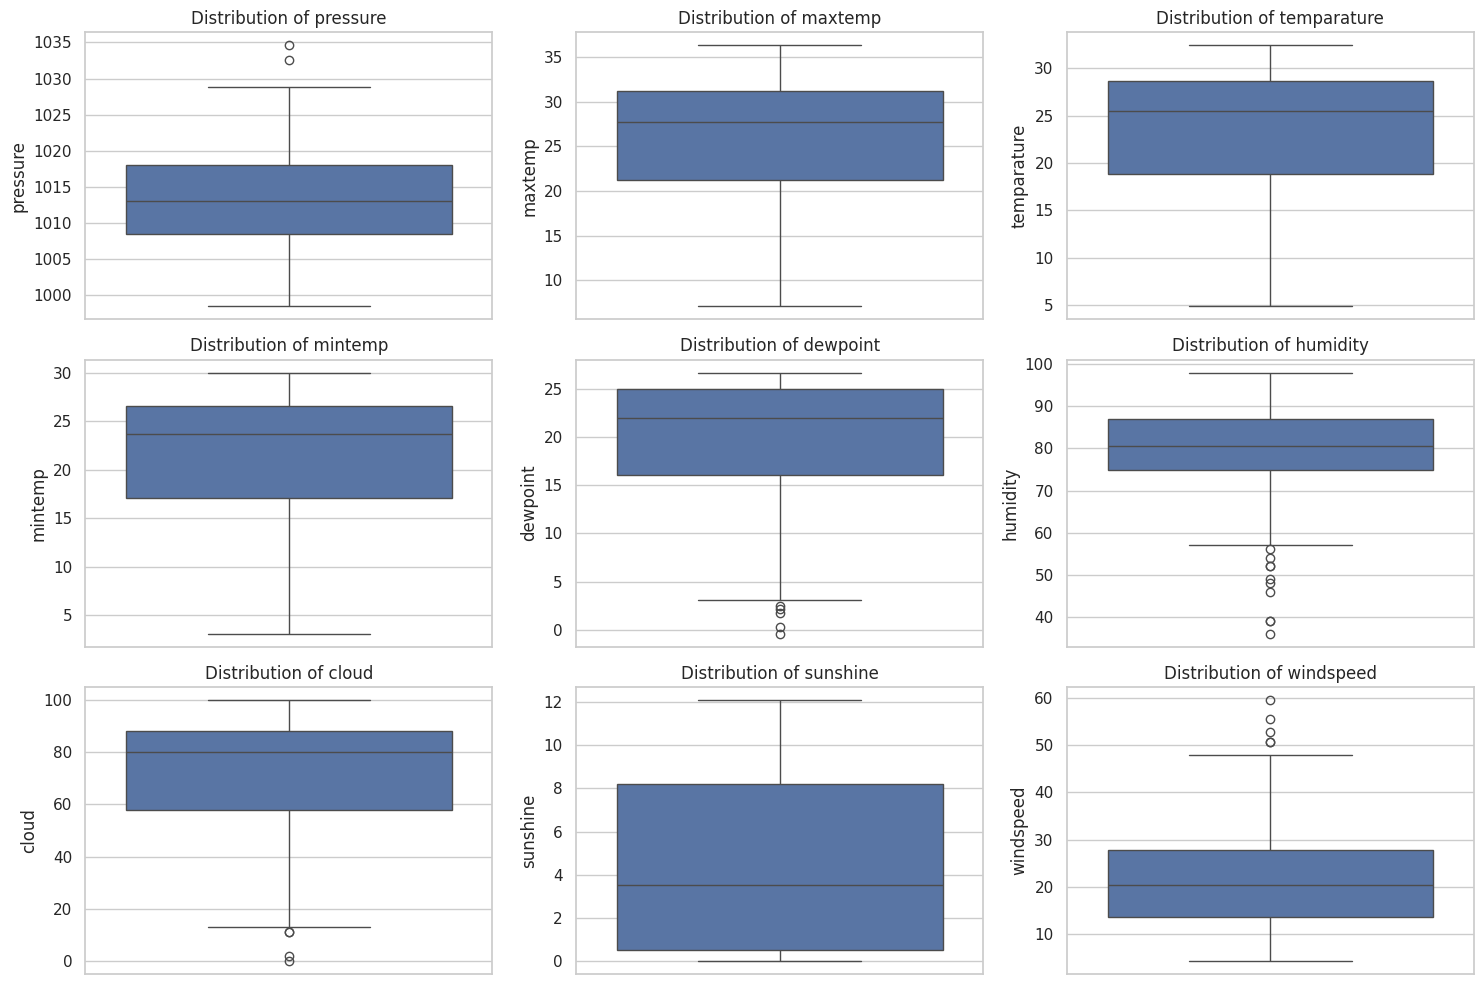

In [ ]:
plt.figure(figsize=(15,10))
for index, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'sunshine',  'windspeed']):
  plt.subplot(3,3,index + 1)
  sns.boxplot(df[column])
  plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [ ]:
df=df.drop(['maxtemp', 'temparature', 'mintemp'],axis=1)

In [ ]:
df.head(3)

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2


In [ ]:
df_maj=df[df['rainfall']==1]
df_min=df[df['rainfall']==0]

In [ ]:
df_maj_downsampled= resample(df_maj , replace=False, n_samples= len(df_min),random_state=42)

In [ ]:
df_maj_downsampled.shape

(117, 8)

In [ ]:
df_down=pd.concat([df_maj_downsampled,df_min])

In [ ]:
df_down.head(3)

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5


In [ ]:
df_down_shuffle= df_down.sample(frac=1,random_state=42).reset_index(drop=True)

In [ ]:
df_down_shuffle.head(3)

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7


In [ ]:
x=df_down_shuffle.drop(['rainfall'],axis=1)
y=df_down_shuffle['rainfall']

In [ ]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=RandomForestClassifier(random_state=42)

In [ ]:
param_grid_rf={
    "n_estimators":[50,100,200],
    "max_features":['sqrt','log2'],
    "max_depth":[None,10,20,30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [ ]:
grid_searc_rf=GridSearchCV(estimator=model,param_grid=param_grid_rf,cv=5,n_jobs=-1,verbose=2)
grid_searc_rf.fit(x_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
best_model=grid_searc_rf.best_estimator_

In [ ]:
cv_scores=cross_val_score(best_model,x_train,y_train,cv=5)


In [ ]:
y_pred=best_model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.7446808510638298

In [ ]:
confusion_matrix(y_test,y_pred)

array([[17,  7],
       [ 5, 18]])

In [ ]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.77      0.71      0.74        24\n           1       0.72      0.78      0.75        23\n\n    accuracy                           0.74        47\n   macro avg       0.75      0.75      0.74        47\nweighted avg       0.75      0.74      0.74        47\n'